In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
model_name = 'extendedDoubleEmb'


for s in range(10):
    weights = torch.load(f'../checkpoints/{model_name}/split_{s}/checkpoint_best.pt')
    break

In [2]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def get_dist_weight(dist, smooth, force):
    return sigmoid(smooth / (1 + dist) - force * smooth) / sigmoid(smooth - force * smooth)

def get_weighted_dist(dist, smooth, force):
    return 1 / (1 + dist) * get_dist_weight(dist, smooth, force)

In [5]:
weights

{'model_state_dict': OrderedDict([('global_lamb', tensor(2.1368)),
              ('alpha', tensor(0.7431)),
              ('beta', tensor(-0.0650)),
              ('gamma', tensor(1.7450)),
              ('cutoff', tensor(4.0056)),
              ('smooth', tensor(1.8172)),
              ('force', tensor(1.8125)),
              ('history_items',
               tensor([[   0,    0,    0,  ...,    0,    0,    0],
                       [   1,    2,    3,  ...,    0,    0,    0],
                       [ 576,  211,  577,  ...,    0,    0,    0],
                       ...,
                       [ 678,  276,  319,  ...,    0,    0,    0],
                       [1471, 2822, 2701,  ...,    0,    0,    0],
                       [ 699,  455,  396,  ...,    0,    0,    0]])),
              ('history_times',
               tensor([[         0,          0,          0,  ...,          0,          0,
                                 0],
                       [1654072390, 1654072708, 1654072940,  

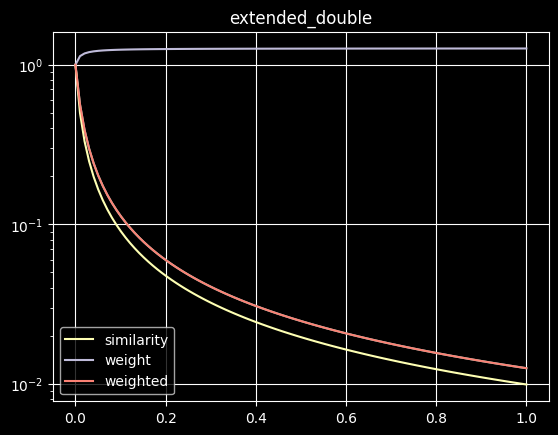

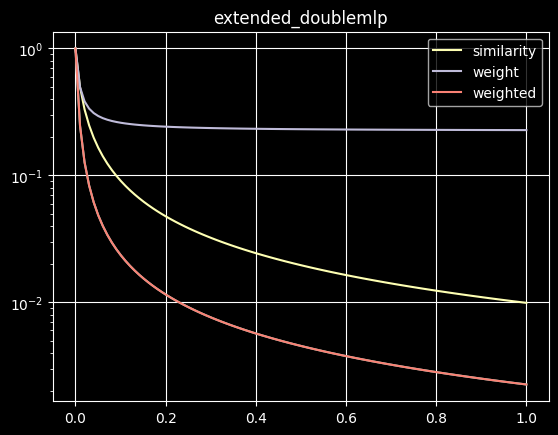

In [3]:
weight_path = '../train_notebooks/weights'

for m in ['extended_double', 'extended_doublemlp']:
    df_list = []
    weights_list = []

    weights = torch.load(f'{weight_path}/{m}/weights.pt', map_location='cpu', weights_only=False)

    a = 0
    b = 1

    smooth = weights['model_state_dict']['smooth'].cpu().numpy()
    force = weights['model_state_dict']['force'].cpu().numpy()

    plt.figure()
    plt.plot(np.linspace(a, b, 100), get_weighted_dist(np.linspace(0, 100, 100), smooth, force))
    plt.plot(np.linspace(a, b, 100), 1 / (1 + np.linspace(0, 100, 100)), label='similarity')
    plt.plot(np.linspace(a, b, 100), get_dist_weight(np.linspace(0, 100, 100), smooth, force), label='weight')
    plt.plot(np.linspace(a, b, 100), get_weighted_dist(np.linspace(0, 100, 100), smooth, force), label='weighted')
    plt.legend()
    plt.grid()
    plt.title(m)
    plt.yscale('log')




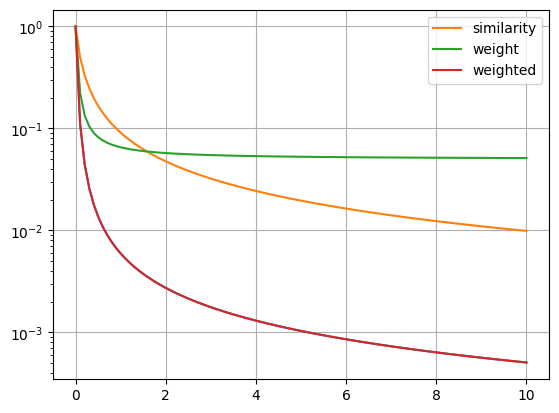

In [25]:
a = 0
b = 10

plt.plot(np.linspace(a, b, 100), get_weighted_dist(np.linspace(0, 100, 100), 3, 4))
plt.plot(np.linspace(a, b, 100), 1 / (1 + np.linspace(0, 100, 100)), label='similarity')
plt.plot(np.linspace(a, b, 100), get_dist_weight(np.linspace(0, 100, 100), 3, 4), label='weight')
plt.plot(np.linspace(a, b, 100), get_weighted_dist(np.linspace(0, 100, 100), 3, 4), label='weighted')
plt.legend()
plt.grid()
plt.yscale('log')

In [8]:
weights['model_state_dict']

OrderedDict([('global_lamb', tensor(3.3229, device='cuda:0')),
             ('alpha', tensor(0.5632, device='cuda:0')),
             ('beta', tensor(0.0563, device='cuda:0')),
             ('gamma', tensor(-0.4594, device='cuda:0')),
             ('cutoff', tensor(32.7334, device='cuda:0')),
             ('smooth', tensor(3.0987, device='cuda:0')),
             ('force', tensor(4.2430, device='cuda:0')),
             ('user_lamb.weight',
              tensor([[ 0.5299],
                      [-0.1535],
                      [-0.7443],
                      ...,
                      [ 0.8645],
                      [ 0.4340],
                      [-1.3027]], device='cuda:0')),
             ('user_bias.weight',
              tensor([[-1.6697],
                      [ 0.0017],
                      [ 0.3118],
                      ...,
                      [ 1.0611],
                      [ 0.8715],
                      [ 0.3846]], device='cuda:0')),
             ('item_bias.weight',
